# Block C, Year 1: Responsible AI Template

Name: Ceren

Number: 243910

Please, use this template implement and document your solutions to the Responsible AI tasks as described in the [DataLab Tasks](https://adsai.buas.nl/Year1/BlockC/DataLabTasks.html) page. If you have any questions, please, contact your mentor or the content responsible. 

## Important Notes:

- [ ] Please, rename the file to ``Responsible-AI-YOUR_NAME-STUDENT_NUMBER.ipynb``. 
- [ ] You are allowed to add as many Markdown/Python cells as you need. 
- [ ] You are required to provide textual explanations on all tasks. Please use the markdown cells to explain all your decisions.
- [ ] If certain Markdown/Python cells were not used, please remove them from the final version of your file. 
- [ ] You must replace the instructions in the template sections with your own content.
- [ ] Your work must be reproducible, meaning that we should be able to run your code in the template and get similar results to yours. Tip: use relative paths to load your data, and do not forget to include the requirements.txt file for XAI!
- [ ] Ensure that before you hand in the template, you press ```Restart & Run all```; we should be able to see the results of your code in the notebook (i.e., output cells).
- [ ] Ensure that your code in the template is ```error-free```. In other words, we should not see any error messages when we run your code.

## Task 2.2: Identify and Describe Bias


The dataset used for this project consists of images categorized into two classes: healthy plants and unhealthy plants. Although the data focuses on plant health rather than human attributes, there exist important biases that can indirectly affect the application's users.

Bias Identification
A key bias in the dataset is the uneven representation of different plant species and types of diseases. Common or popular plants are overrepresented, while rare or exotic plants, as well as uncommon diseases, are underrepresented. This class imbalance can lead to a model that performs well on majority classes but poorly on minority classes, resulting in inaccurate or inconsistent predictions.

Impact of Bias
Although this bias does not cause direct harm to individuals, it can have negative consequences for plant owners relying on the app. If the model cannot correctly identify diseases or health conditions for underrepresented plants, users may receive incorrect care advice. This can lead to poor plant health outcomes, such as progression of disease or plant death, which may cause emotional distress and reduce users’ trust in the application.

Disproportionately Impacted Groups
Plant owners who possess rare, exotic, or less common plant species are disproportionately affected. Their plants may not receive accurate diagnosis or care recommendations due to the model’s bias toward more common species. This creates a representational harm where some users’ needs are insufficiently met.

Context and Consequences
The bias in the dataset risks marginalizing certain plant types and diseases, undermining the overall fairness and effectiveness of the AI system. Over time, this could discourage users with diverse plant collections from using the app, limiting its adoption and usefulness. Addressing these biases is therefore essential to ensure equitable and accurate plant health diagnostics for all users.

In [ ]:
import pandas as pd
import os


print("Current Working Directory:", os.getcwd())

# Path data set
file_path = r'C:\Users\cerre\Desktop\Mydata\healthy\health.csv'


if os.path.exists(file_path):
    # Download data set
    data = pd.read_csv(file_path)

    
    print(data.head())
else:
    print(f"Error: The file at {file_path} does not exist.")


Current Working Directory: c:\Users\cerre\Desktop\WORK 2\2024-25c-fai1-adsai-CerenKurt243910\Deliverables
Error: The file at C:\Users\cerre\Desktop\Mydata\healthy\health.csv does not exist.


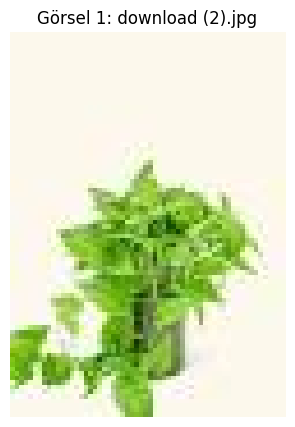

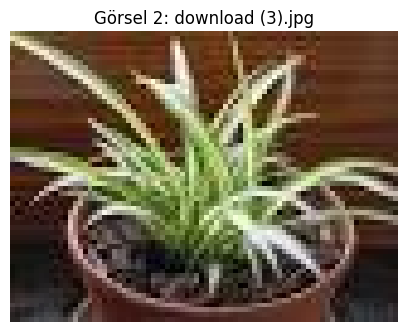

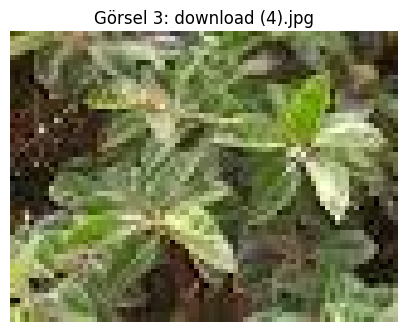

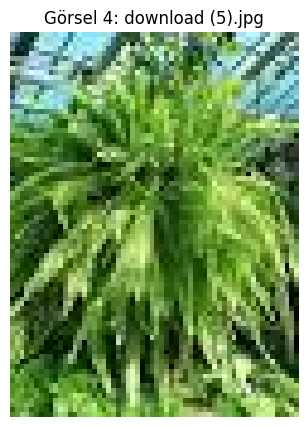

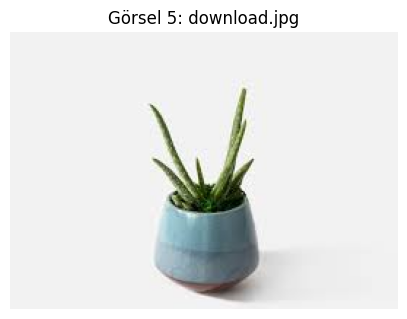

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory containing images
image_folder = "C:\\Users\\cerre\\Desktop\\healthy"

# List all image files in the directory (jpg and png)
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]

# Display the first 5 images
for i, img_file in enumerate(image_files[:5]):
    img_path = os.path.join(image_folder, img_file)
    img = mpimg.imread(img_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Image {i + 1}: {img_file}")
    plt.axis('off')  # Turn off axes
    plt.show()


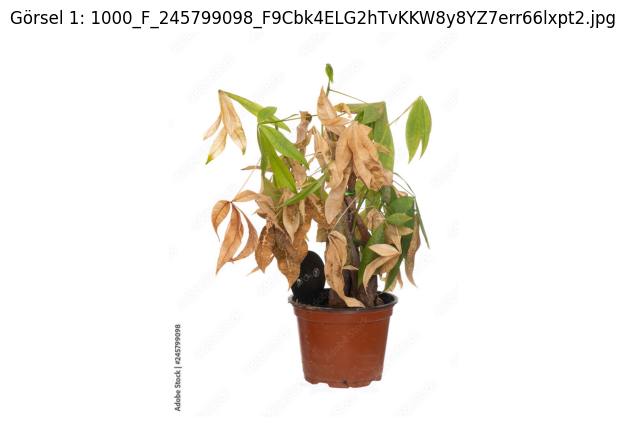

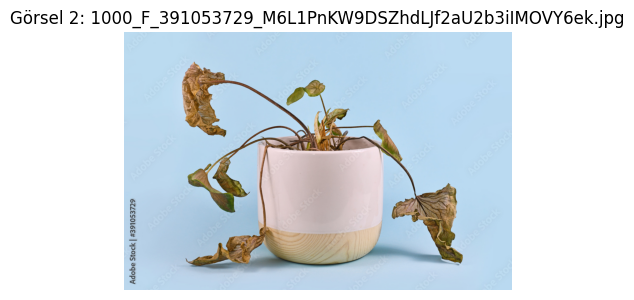

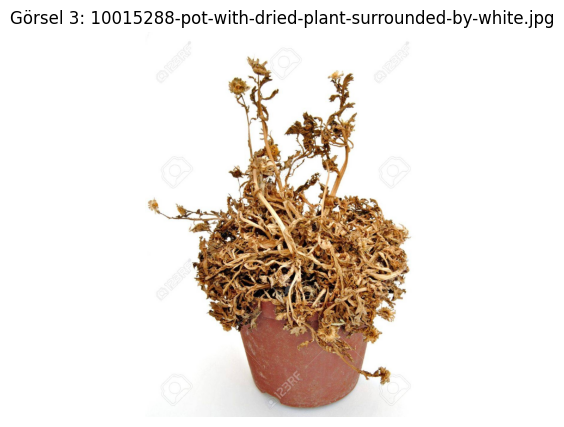

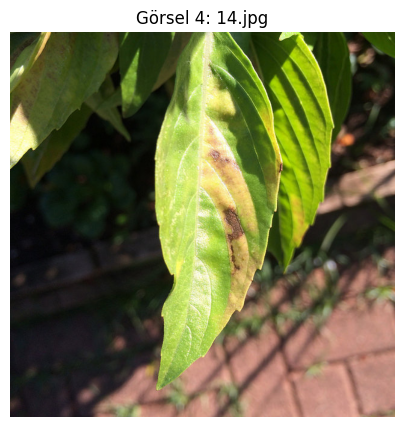

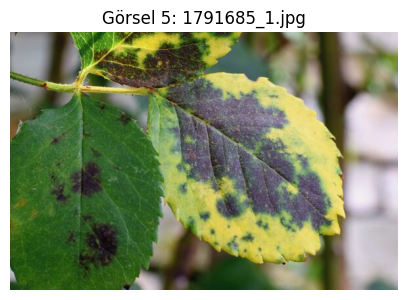

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory containing images
image_folder = "C:\\Users\\cerre\\Desktop\\unhealthy"

# List all image files in the directory (jpg and png)
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]

# Display the first 5 images
for i, img_file in enumerate(image_files[:5]):
    img_path = os.path.join(image_folder, img_file)
    img = mpimg.imread(img_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Image {i + 1}: {img_file}")
    plt.axis('off')  # Turn off axes
    plt.show()



## Task 2.3: Propose Individual Fairness Method


For this task, I chose **Fairness Through Awareness** to address potential bias in the plant care dataset. This method involves making the dataset more inclusive by adding underrepresented plant types, such as rare or difficult-to-care-for plants, to ensure that the model is trained on a broader range of plants.

The reason for choosing this method is that the dataset may be biased towards easy-to-care-for plants (like succulents), which could affect users with more complex plants. By adding images of a diverse range of plants, I can help the model provide more accurate care advice to a wider group of plant owners.

In practice, I would add images of rare plants to the dataset, ensuring that the model doesn’t neglect these types. This would make the model fairer and more representative of real-world plant care.

In [8]:
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import os

# Path to your dataset
data_path = 'C:/Users/cerre/Desktop/Mydata'

# Define the data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Get the list of all plant images you want to augment
plant_images = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.jpg')]

# Loop over each plant image and generate augmented images
for img_path in plant_images:
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1,) + img_array.shape)  # Reshape for ImageDataGenerator

    # Generate and save augmented images
    i = 0
    for batch in datagen.flow(img_array, save_to_dir='C:/Users/cerre/Desktop/Mydata/augmented', save_prefix='aug', save_format='jpeg'):
        i += 1
        if i > 20:  # Generate 20 augmented images per original image
            break

print("Data augmentation complete!")


Data augmentation complete!


## Task 2.4: Create Infographic; Group Fairness Metrics

__1. Strengths__
Filled in by yourself and your peer, separately
Peer Reviewer: Asma Moghimi
Strengths of the Infographic:
The infographic provides a clear and concise introduction to the concept of group fairness in machine learning, with accessible explanations for each metric.
The use of color contrasts and simple charts helps to break down complex information into digestible portions.
The inclusion of real-world use cases makes the theoretical concepts more relatable, showing practical applications of fairness metrics.
The visual elements, such as graphs and icons, effectively highlight the differences between fairness metrics, making comparisons easier to understand.
__2. Areas for Improvement__
-Peer Reviewer: Asma Moghimi
Areas for Improvement of the Infographic:
The text could be more concise in some sections to further enhance clarity and ease of understanding.
The choice of color scheme could be adjusted to ensure better contrast and visibility, particularly for text-heavy sections.
The visual flow of the infographic can be improved by better organizing the metrics, ensuring that each is clearly separated and easily comparable.
Including a brief summary or conclusion at the bottom could help reinforce the main takeaways for the reader.

__3. Next Steps for Improvement__
-  Peer Reviewer: Asma Moghimi
Actionable Steps for Improvement of the Infographic:
Rework text: Simplify and condense the text in some areas to make the information more digestible for the reader.
Improve contrast: Experiment with different color schemes to make the text and visuals stand out more, improving readability.
Enhance visual flow: Rearrange the layout of the metrics to ensure they follow a logical flow, making comparisons clearer.
Add a summary section: Include a brief conclusion at the bottom of the infographic that summarizes the key insights and implications of the group fairness metrics.
Seek further feedback: After implementing these changes, share the revised infographic with peers for more feedback to ensure clarity and engagement.

__4. Reflection__
Reflection on My Infographic and the Feedback I Received from My Peer Reviewer:
Reflecting on the infographic, I believe it successfully explains the key group fairness metrics in a visually engaging way. The use of colors and icons helps break down complex concepts into easily understandable sections. However, the feedback from my peer, Asma, highlighted a few areas for improvement, particularly in simplifying the text and adjusting the contrast for better readability. I also realized that while the visuals are engaging, the flow between the metrics can be enhanced for smoother comprehension.
I appreciate the constructive feedback and plan to make the necessary adjustments, including reworking the text and experimenting with different layouts. After these changes, I’ll seek further feedback to ensure the infographic is both informative and visually appealing.

__5. Infographic__
![- \[Add the link to your infographic here\]](https://github.com/BredaUniversityADSAI/2024-25c-fai1-adsai-CerenKurt243910/blob/main/Week%206/infograph.png)

## Task 2.5: Apply an Explainable AI Method to the Image Classifier

__Virtual Environment:__
For this task, I applied Explainable AI (XAI) methods to my image classifier based on the EfficientNetB0 architecture to enhance its transparency and interpretability. The primary goal was to make the model's decision-making process more understandable to humans by visualizing which regions of an input image influenced the classification. I implemented Grad-CAM (Gradient-weighted Class Activation Mapping) as the main XAI method to highlight important image areas contributing to the model’s predictions. Additionally, I explored LIME (Local Interpretable Model-agnostic Explanations) as an alternative approach to provide complementary insights into the model’s behavior on individual images. These methods together help in diagnosing model focus areas and building trust in the AI system’s outputs.



In [9]:
pip install numpy==1.23.5


Note: you may need to restart the kernel to use updated packages.


Add your text here.

In [10]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install tf-keras-vis


Note: you may need to restart the kernel to use updated packages.


In [2]:
conda install -c conda-forge tf-keras-vis


Retrieving notices: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... failed

Note: you may need to restart the kernel to use updated packages.



PackagesNotFoundError: The following packages are not available from current channels:

  - tf-keras-vis

Current channels:

  - https://conda.anaconda.org/conda-forge
  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [12]:
from tf_keras_vis.gradcam import Gradcam


In [17]:
# Batch dimensionunu at
last_conv_layer_output = last_conv_layer_output[0]  # (14, 14, 512)

# pooled_grads zaten (512,)
# Tensordot ile kanallar üzerinde çarpma yapıyoruz
heatmap = np.tensordot(last_conv_layer_output, pooled_grads.numpy(), axes=([2], [0]))  # (14, 14)

# ReLU
heatmap = np.maximum(heatmap, 0)

# Normalize
heatmap /= np.max(heatmap)


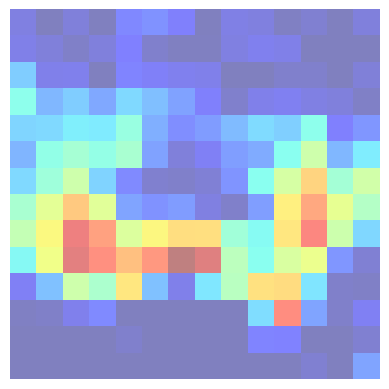

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
import tensorflow as tf  # GradientTape için

# Load the pre-trained VGG16 model with ImageNet weights
model = VGG16(weights='imagenet')

# Load an image you want to test
img_path = "C:/Users/cerre/Desktop/healthy/healthy_041.jpg"  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Preprocess image for VGG16
img_array = preprocess_input(img_array)

# Select the last convolutional layer for Grad-CAM
last_conv_layer = model.get_layer('block5_conv3')

# Create a model to access the output of the last convolutional layer and final predictions
grad_model = Model(inputs=model.input, outputs=[last_conv_layer.output, model.output])

# Compute the gradient of the top predicted class with regard to the last convolutional layer
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(img_array)
    class_channel = preds[:, tf.argmax(preds[0])]
    grads = tape.gradient(class_channel, last_conv_layer_output)

# Pool the gradients over all the axes (width, height)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Compute the weighted sum of the feature maps
heatmap = np.tensordot(last_conv_layer_output[0], pooled_grads.numpy(), axes=([2], [0]))

# Apply ReLU and normalize
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Display the original image with the heatmap overlay
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with color map
plt.axis('off')
plt.show()


In [23]:
pip install opencv-python


  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Note: you may need to restart the kernel to use updated packages.


21834768/21834768 [==============================] - 1s 0us/step


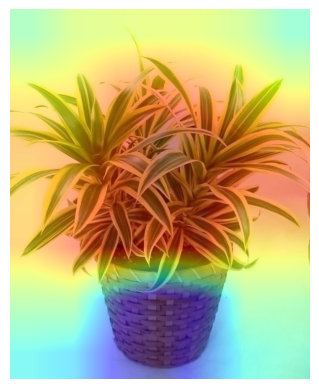

35363/35363 [==============================] - 0s 1us/step
Predictions:
1. pot: 0.9039
2. vase: 0.0098
3. shopping_basket: 0.0064
4. hamper: 0.0046
5. pineapple: 0.0044


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
from tensorflow.keras.models import Model
import cv2

# 1. Load the model (pre-trained on ImageNet)
model = EfficientNetB0(weights='imagenet')

# 2. Load and preprocess the image
img_path = "C:/Users/cerre/Desktop/healthy/healthy_041.jpg"  # Adjust path accordingly
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# 3. Select the last convolutional layer
last_conv_layer = model.get_layer('top_conv')

# 4. Create model for Grad-CAM that outputs last conv layer and predictions
grad_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, model.output])

# 5. Calculate gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)

# 6. Compute weights by global average pooling
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# 7. Weight the convolution outputs
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

# 8. Normalize heatmap and apply ReLU
heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

# 9. Load original image (color)
img_orig = image.load_img(img_path)
plt.imshow(img_orig)

# 10. Resize heatmap to original image size
heatmap = cv2.resize(heatmap, (img_orig.size[0], img_orig.size[1]))

# 11. Overlay heatmap on original image with transparency
plt.imshow(heatmap, cmap='jet', alpha=0.5)

plt.axis('off')
plt.show()

# 12. Display predicted labels and scores
decoded_preds = decode_predictions(predictions.numpy())[0]
print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_preds):
    print(f"{i+1}. {label}: {score:.4f}")


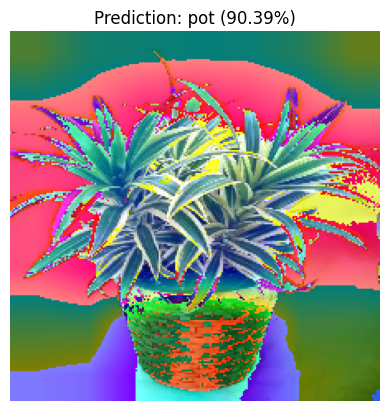

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input, decode_predictions
from tensorflow.keras.models import Model
import tensorflow as tf

# Load the model
model = EfficientNetB0(weights='imagenet')

# Load and preprocess the image
img_path = "C:/Users/cerre/Desktop/healthy/healthy_041.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Select the last convolutional layer
last_conv_layer = model.get_layer('top_conv')

# Create a model that outputs both the last conv layer and the final predictions
grad_model = Model(inputs=model.input, outputs=[last_conv_layer.output, model.output])

# Calculate Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Resize heatmap to original image size
import cv2
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
heatmap = np.uint8(255 * heatmap)

# Apply color map to heatmap
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap on original image with 0.5 opacity
superimposed_img = heatmap * 0.5 + np.array(img)

# Display the image
plt.imshow(superimposed_img.astype(np.uint8))
plt.axis('off')

# Print predicted class label and probability
decoded = decode_predictions(predictions.numpy())[0][0]
plt.title(f"Prediction: {decoded[1]} ({decoded[2]*100:.2f}%)")

plt.show()



In [26]:
pip install shap


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/544.9 kB ? eta -:--:--
   ---------------------------------------- 544.9/544.9 kB 9.1 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 38.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ----------------------- ---------------- 16.5/28.1 MB 74.2 MB/s eta 0:00:01
   ---------------------------------------- 28.1/28.1 MB 71.3 MB/s eta 0:00:00
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.1-py3-none-any.whl (2

In [6]:
pip install lime 

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   --------------------- ------------------ 6.8/12.9 MB 52.4 MB/s eta 0:00:01
   ---------------------- ----------------- 7.3/12.9 MB 32.3 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.9 MB 20.7 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 19.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 12.6 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283919 sha256=bc2fa3a66d3379eb8f617baee445ca437e5aac567dd821bd2ed69297220af675
  Stored in directory: c:\users\cerre\appdata\local\pip\cache\wheels\ed\d7\c9\5a0130d06d6310bc6cbe55220e6e72dcb8c4eff9a478717066
Successfully built lime

   -------- ------------------------------- 1/5 [networkx]
   ---

  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 1s 930ms/step


  1%|          | 10/1000 [00:01<01:42,  9.67it/s]

1/1 [==============================] - 0s 197ms/step


  2%|▏         | 20/1000 [00:01<00:58, 16.81it/s]

...

 98%|█████████▊| 980/1000 [00:28<00:00, 36.02it/s]

1/1 [==============================] - 0s 193ms/step


 99%|█████████▉| 990/1000 [00:28<00:00, 35.54it/s]

1/1 [==============================] - 0s 194ms/step


100%|██████████| 1000/1000 [00:28<00:00, 34.60it/s]


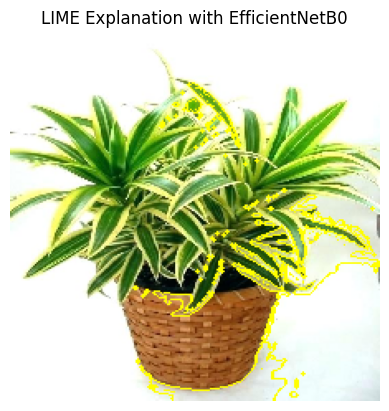

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Load the model (with ImageNet weights)
model = EfficientNetB0(weights='imagenet')

# Load and resize the image
img_path = "C:/Users/cerre/Desktop/healthy/healthy_041.jpg"  # Use your own file path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Prediction function for LIME
def predict_fn(images):
    images_preprocessed = preprocess_input(images.copy())
    return model.predict(images_preprocessed)

# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation for the image (increase num_samples, e.g. 1000, if needed)
explanation = explainer.explain_instance(
    img_array.astype('double'), 
    predict_fn, 
    top_labels=5, 
    hide_color=0, 
    num_samples=1000
)

# Get positive contributions for the top predicted class
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)

# Plot the result
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.title('LIME Explanation with EfficientNetB0')
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 1s 1s/step


  1%|          | 10/1000 [00:01<02:08,  7.73it/s]

1/1 [==============================] - 0s 194ms/step


  2%|▏         | 20/1000 [00:01<01:08, 14.37it/s]

...

 98%|█████████▊| 980/1000 [00:27<00:00, 36.09it/s]

1/1 [==============================] - 0s 198ms/step


 99%|█████████▉| 990/1000 [00:28<00:00, 35.95it/s]

1/1 [==============================] - 0s 205ms/step


100%|██████████| 1000/1000 [00:28<00:00, 35.35it/s]


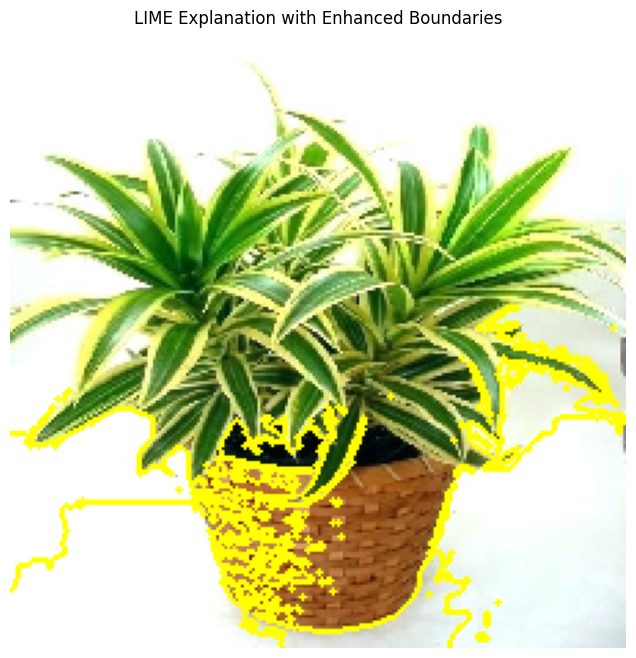

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img_path = "C:/Users/cerre/Desktop/healthy/healthy_041.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Model loaded (EfficientNetB0)
from tensorflow.keras.applications import EfficientNetB0
model = EfficientNetB0(weights='imagenet')

# Prediction function
def predict_fn(images):
    images = preprocess_input(images)
    return model.predict(images)

# LIME Explainer
explainer = lime_image.LimeImageExplainer()

# Generate LIME explanation
explanation = explainer.explain_instance(
    img_array.astype('double'),
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# Index of the highest scoring label
top_label = explanation.top_labels[0]

# Plot image, thicken boundaries and set color to yellow
temp, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(8,8))
plt.title("LIME Explanation with Enhanced Boundaries")
plt.imshow(mark_boundaries(temp / 255.0, mask, color=(1, 1, 0), mode='thick'))  # Yellow thick boundaries
plt.axis('off')
plt.show()


Conclusion

In this project, I applied explainable AI techniques to a deep learning model that classifies plant health. To better understand and visualize how the model makes decisions, I used Grad-CAM and LIME methods.

With Grad-CAM, I was able to highlight the specific areas of the plant images that the model focuses on when making its predictions. LIME helped me explain the model’s decisions by showing which parts of the image influenced the classification the most, on a superpixel level. These techniques demonstrated that the model’s decision-making process is not a black box, but something that can be interpreted and analyzed.

Using these explainability methods improves the trustworthiness of the AI system and helps identify potential errors or biases. For future work, I plan to explore other explainability methods and test them with real users to further improve the model’s transparency and usability